In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import durbin_watson


from statsmodels.tsa.seasonal import STL
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [ ]:
# Load the dataset
data = pd.read_csv('/content/Final1.csv')

In [ ]:
data['EXECUTION_START_DATE'] = pd.to_datetime(data['EXECUTION_START_DATE'], format='%d-%m-%Y')


In [ ]:

df = pd.DataFrame(data)

# Retain only necessary columns
columns_to_keep = [
    'PRODUCTION_LOCATION','EQUIPMENT_ID','EXECUTION_START_DATE', 'ACTUAL_WORK_IN_MINUTES',
    'TIME_TO_FIRST_USE', 'TOTAL_LIFESPAN', 'USABLE_DURATION', 'TIME_USED_TO_LIFESPAN_RATIO',
    'MAINTENANCE_FREQUENCY', 'MAINTENANCE_DURATION_DEVIATION', 'MAINTENANCE_MONTH',
    'MAINTENANCE_QUARTER', 'MAINTENANCE_YEAR', 'FAILURE_RISK_SCORE', 'Risk_Level'
]
df_cleaned = df[columns_to_keep]

df_cleaned['EXECUTION_START_DATE'] = pd.to_datetime(df_cleaned['EXECUTION_START_DATE'])
#df_cleaned['Risk_Level'] = df_cleaned['Risk_Level'].map({'Low Risk': 0, 'Medium Risk': 1, 'High Risk': 2})


# Step 2: Group Data by Location and Resample Monthly
locations = df_cleaned['PRODUCTION_LOCATION'].unique()
location_data = {location: df_cleaned[df_cleaned['PRODUCTION_LOCATION'] == location] for location in locations}



<ipython-input-4-e7b380890a5f>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['EXECUTION_START_DATE'] = pd.to_datetime(df_cleaned['EXECUTION_START_DATE'])


Fitting 2 folds for each of 20 candidates, totalling 40 fits


<ipython-input-5-7632897b8481>:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Risk_Level'] = data['Risk_Level'].map({'Low Risk': 0, 'Medium Risk': 1, 'High Risk': 2})
<ipython-input-5-7632897b8481>:45: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data_resampled = data.resample('M').agg({
<ipython-input-5-7632897b8481>:76: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X['trend'] = data_resampled['trend'].shift(1).fillna(method='bfill')
<ipython-input-5-7632897b8481>:77: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() inst

Fitting 2 folds for each of 9 candidates, totalling 18 fits


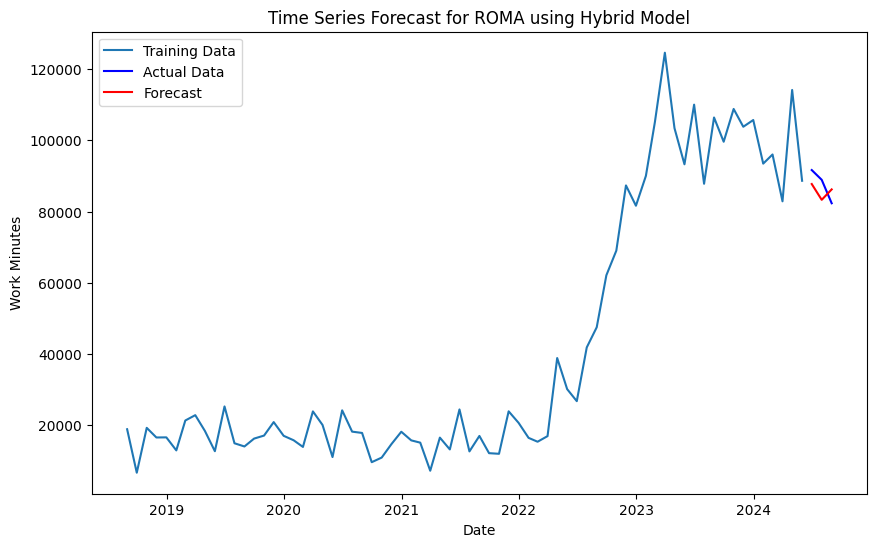

Location: ROMA - MAE: 4477.5852591455, RMSE: 4549.965265947203
Random Search Best Params for ROMA: {'subsample': 0.8, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 9, 'learning_rate': 0.01, 'lambda': 2, 'colsample_bytree': 0.8, 'alpha': 0}
Grid Search Best Params for ROMA: {'alpha': 0, 'colsample_bytree': 0.8, 'lambda': 2, 'learning_rate': 0.01, 'max_depth': 8, 'min_child_weight': 5, 'n_estimators': 100, 'subsample': 0.8}
Fitting 2 folds for each of 20 candidates, totalling 40 fits


<ipython-input-5-7632897b8481>:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Risk_Level'] = data['Risk_Level'].map({'Low Risk': 0, 'Medium Risk': 1, 'High Risk': 2})
<ipython-input-5-7632897b8481>:45: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data_resampled = data.resample('M').agg({
<ipython-input-5-7632897b8481>:76: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X['trend'] = data_resampled['trend'].shift(1).fillna(method='bfill')
<ipython-input-5-7632897b8481>:77: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() inst

Fitting 2 folds for each of 9 candidates, totalling 18 fits


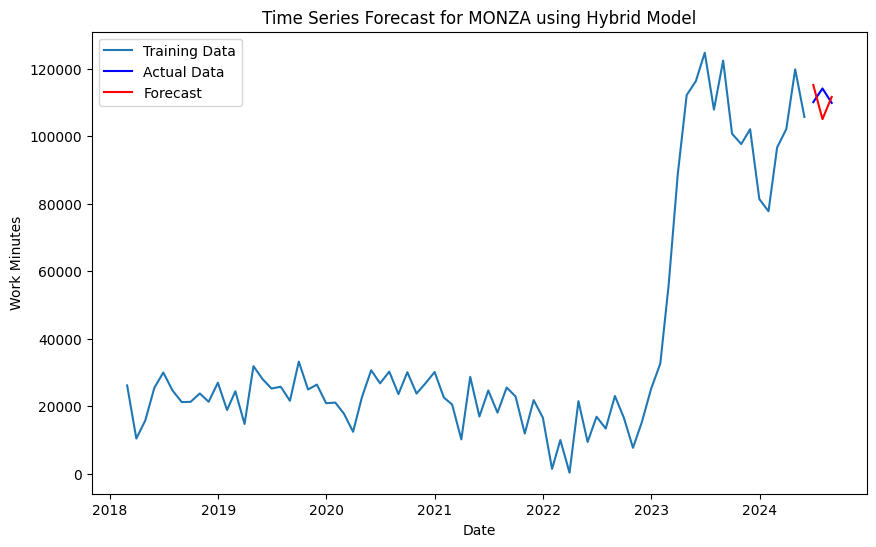

Location: MONZA - MAE: 5310.050985689799, RMSE: 6094.757210223201
Random Search Best Params for MONZA: {'subsample': 0.8, 'n_estimators': 50, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.01, 'lambda': 1, 'colsample_bytree': 0.8, 'alpha': 1}
Grid Search Best Params for MONZA: {'alpha': 1, 'colsample_bytree': 0.8, 'lambda': 1, 'learning_rate': 0.01, 'max_depth': 8, 'min_child_weight': 3, 'n_estimators': 50, 'subsample': 0.8}
Fitting 2 folds for each of 20 candidates, totalling 40 fits


<ipython-input-5-7632897b8481>:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Risk_Level'] = data['Risk_Level'].map({'Low Risk': 0, 'Medium Risk': 1, 'High Risk': 2})
<ipython-input-5-7632897b8481>:45: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data_resampled = data.resample('M').agg({
<ipython-input-5-7632897b8481>:76: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X['trend'] = data_resampled['trend'].shift(1).fillna(method='bfill')
<ipython-input-5-7632897b8481>:77: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() inst

Fitting 2 folds for each of 9 candidates, totalling 18 fits


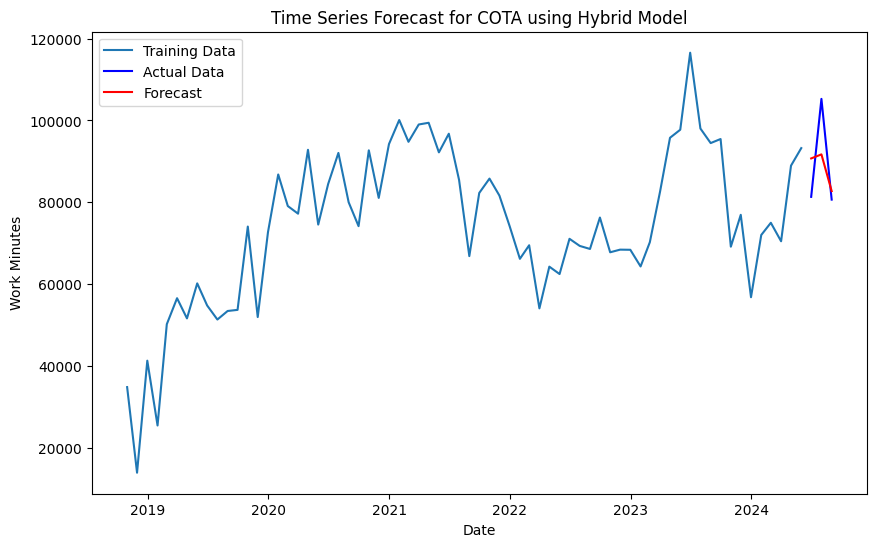

Location: COTA - MAE: 8339.983283913365, RMSE: 9594.809604268752
Random Search Best Params for COTA: {'subsample': 1.0, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.1, 'lambda': 2, 'colsample_bytree': 0.8, 'alpha': 0.1}
Grid Search Best Params for COTA: {'alpha': 0.1, 'colsample_bytree': 0.8, 'lambda': 2, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 50, 'subsample': 1.0}
Fitting 2 folds for each of 20 candidates, totalling 40 fits


<ipython-input-5-7632897b8481>:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Risk_Level'] = data['Risk_Level'].map({'Low Risk': 0, 'Medium Risk': 1, 'High Risk': 2})
<ipython-input-5-7632897b8481>:45: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data_resampled = data.resample('M').agg({
<ipython-input-5-7632897b8481>:76: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X['trend'] = data_resampled['trend'].shift(1).fillna(method='bfill')
<ipython-input-5-7632897b8481>:77: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() inst

Fitting 2 folds for each of 9 candidates, totalling 18 fits


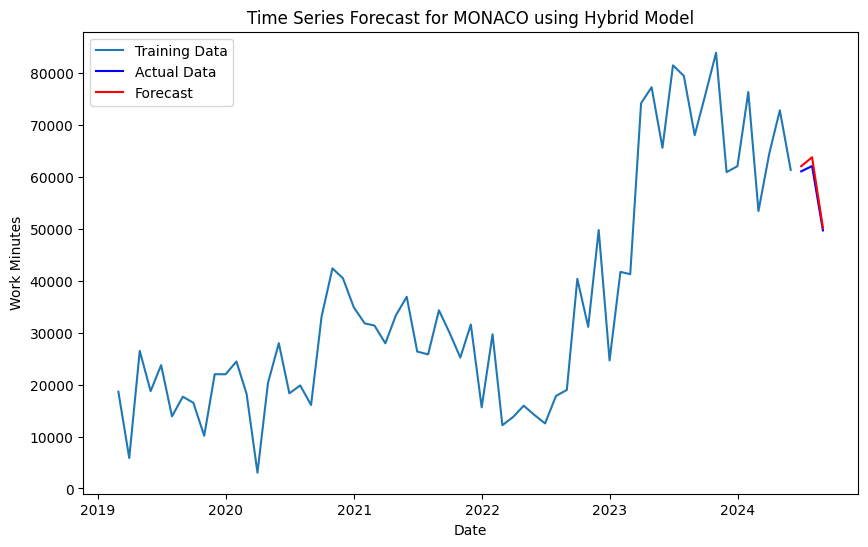

Location: MONACO - MAE: 1075.7523827318485, RMSE: 1179.391151362845
Random Search Best Params for MONACO: {'subsample': 1.0, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.01, 'lambda': 1, 'colsample_bytree': 0.6, 'alpha': 1}
Grid Search Best Params for MONACO: {'alpha': 1, 'colsample_bytree': 0.6, 'lambda': 1, 'learning_rate': 0.01, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 1.0}
Fitting 2 folds for each of 20 candidates, totalling 40 fits


<ipython-input-5-7632897b8481>:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Risk_Level'] = data['Risk_Level'].map({'Low Risk': 0, 'Medium Risk': 1, 'High Risk': 2})
<ipython-input-5-7632897b8481>:45: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data_resampled = data.resample('M').agg({
<ipython-input-5-7632897b8481>:76: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X['trend'] = data_resampled['trend'].shift(1).fillna(method='bfill')
<ipython-input-5-7632897b8481>:77: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() inst

Fitting 2 folds for each of 9 candidates, totalling 18 fits


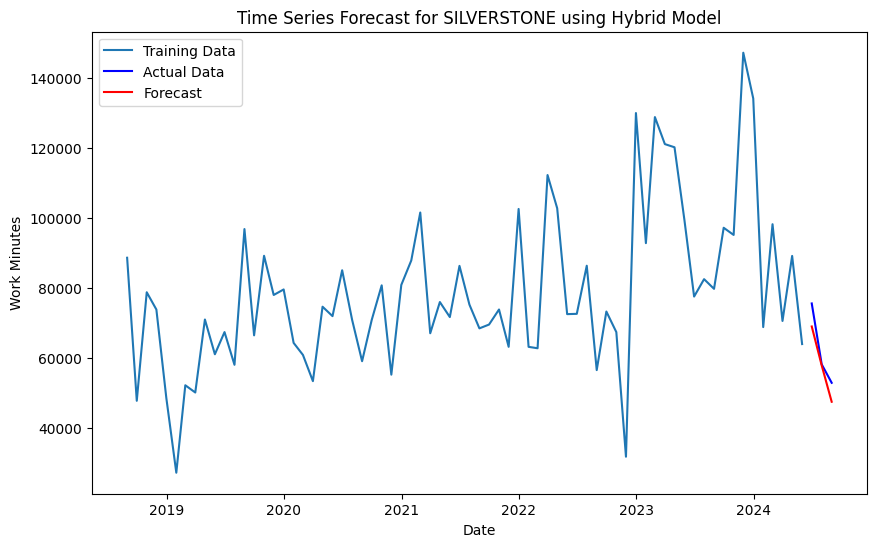

Location: SILVERSTONE - MAE: 4102.84123444821, RMSE: 4923.773692097116
Random Search Best Params for SILVERSTONE: {'subsample': 0.8, 'n_estimators': 50, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.01, 'lambda': 1, 'colsample_bytree': 0.8, 'alpha': 1}
Grid Search Best Params for SILVERSTONE: {'alpha': 1, 'colsample_bytree': 0.8, 'lambda': 1, 'learning_rate': 0.01, 'max_depth': 8, 'min_child_weight': 3, 'n_estimators': 50, 'subsample': 0.8}
Fitting 2 folds for each of 20 candidates, totalling 40 fits


<ipython-input-5-7632897b8481>:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Risk_Level'] = data['Risk_Level'].map({'Low Risk': 0, 'Medium Risk': 1, 'High Risk': 2})
<ipython-input-5-7632897b8481>:45: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data_resampled = data.resample('M').agg({
<ipython-input-5-7632897b8481>:76: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X['trend'] = data_resampled['trend'].shift(1).fillna(method='bfill')
<ipython-input-5-7632897b8481>:77: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() inst

Fitting 2 folds for each of 9 candidates, totalling 18 fits


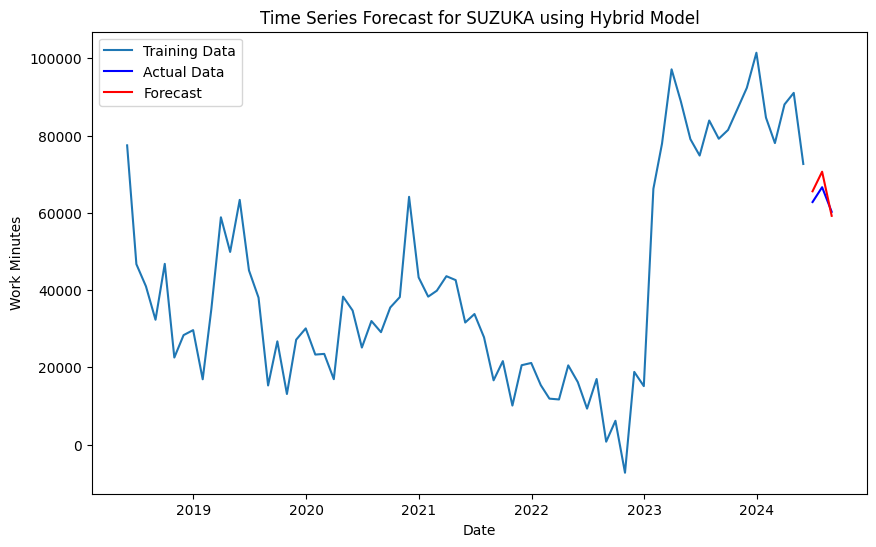

Location: SUZUKA - MAE: 2611.98694777267, RMSE: 2883.2502352227884
Random Search Best Params for SUZUKA: {'subsample': 0.8, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.1, 'lambda': 1, 'colsample_bytree': 1.0, 'alpha': 0.1}
Grid Search Best Params for SUZUKA: {'alpha': 0.1, 'colsample_bytree': 1.0, 'lambda': 1, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 0.8}


In [ ]:

# Store results for each location
forecast_results = {}

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 7, 9],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'alpha': [0, 0.1, 1],  # L1 regularization
    'lambda': [1, 1.5, 2]  # L2 regularization
}

# Function to prepare lagged features and other exogenous variables
def prepare_data(df, target_col, exog_cols, lags=12):
    """
    Prepares data for supervised learning by creating lagged target values
    and adding exogenous variables.
    """
    df = df.copy()

    # Create lagged features for the target variable
    for i in range(1, lags + 1):
        df[f"{target_col}_lag_{i}"] = df[target_col].shift(i)

    # Drop NaN values introduced by lagging
    df.dropna(inplace=True)

    # Select the target, lagged features, and exogenous variables
    feature_cols = [f"{target_col}_lag_{i}" for i in range(1, lags + 1)] + exog_cols
    X = df[feature_cols]
    y = df[target_col]

    return X, y

# Loop through each location in the data
for location in locations:
    data = location_data[location]
    data.set_index('EXECUTION_START_DATE', inplace=True)
    data['Risk_Level'] = data['Risk_Level'].map({'Low Risk': 0, 'Medium Risk': 1, 'High Risk': 2})

    # Monthly resampling and seasonal decomposition
    data_resampled = data.resample('M').agg({
        'ACTUAL_WORK_IN_MINUTES': 'sum',
        'TIME_TO_FIRST_USE': 'mean',
        'TOTAL_LIFESPAN': 'mean',
        'USABLE_DURATION': 'mean',
        'TIME_USED_TO_LIFESPAN_RATIO': 'mean',
        'MAINTENANCE_FREQUENCY': 'mean',
        'MAINTENANCE_DURATION_DEVIATION': 'mean',
        'FAILURE_RISK_SCORE': 'mean',
        'Risk_Level': 'max'
    }).dropna()

    # Seasonal decomposition of target variable
    stl = STL(data_resampled['ACTUAL_WORK_IN_MINUTES'], seasonal=13)
    result = stl.fit()

    # Extract seasonal, trend, and residual components
    data_resampled['trend'] = result.trend
    data_resampled['seasonal'] = result.seasonal
    data_resampled['residual'] = result.resid

    # Define target and features for residual modeling
    target_col = 'residual'
    exog_cols = [
        'TIME_TO_FIRST_USE', 'TOTAL_LIFESPAN', 'USABLE_DURATION',
        'TIME_USED_TO_LIFESPAN_RATIO', 'MAINTENANCE_FREQUENCY',
        'MAINTENANCE_DURATION_DEVIATION', 'FAILURE_RISK_SCORE', 'Risk_Level'
    ]

    # Prepare data with lagged features and additional trend/seasonal indicators
    X, y = prepare_data(data_resampled, target_col, exog_cols)
    X['trend'] = data_resampled['trend'].shift(1).fillna(method='bfill')
    X['seasonal'] = data_resampled['seasonal'].shift(1).fillna(method='bfill')

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=3, shuffle=False)

    # Randomized search with regularization terms
    xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)
    random_search = RandomizedSearchCV(
        estimator=xgb_model,
        param_distributions=param_grid,
        n_iter=20,
        scoring='neg_mean_squared_error',
        cv=2,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )
    random_search.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    # Use best params from RandomizedSearchCV in GridSearchCV for further tuning
    best_params_random = random_search.best_params_
    fine_param_grid = {
        'learning_rate': [best_params_random['learning_rate']],
        'n_estimators': [best_params_random['n_estimators'] - 50, best_params_random['n_estimators'], best_params_random['n_estimators'] + 50],
        'max_depth': [best_params_random['max_depth'] - 1, best_params_random['max_depth'], best_params_random['max_depth'] + 1],
        'min_child_weight': [best_params_random['min_child_weight']],
        'subsample': [best_params_random['subsample']],
        'colsample_bytree': [best_params_random['colsample_bytree']],
        'alpha': [best_params_random['alpha']],
        'lambda': [best_params_random['lambda']]
    }
    grid_search = GridSearchCV(
        estimator=XGBRegressor(objective='reg:squarederror', random_state=42),
        param_grid=fine_param_grid,
        scoring='neg_mean_squared_error',
        cv=2,
        verbose=1,
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    # Final model training
    best_params_grid = grid_search.best_params_
    final_model = XGBRegressor(objective='reg:squarederror', **best_params_grid)
    final_model.fit(X_train, y_train)

    # Make predictions on residuals and add back trend + seasonality
    residual_pred = final_model.predict(X_test)
    forecast = residual_pred + X_test['trend'].values + X_test['seasonal'].values

    # Evaluate forecast on original scale
    mae = mean_absolute_error(y_test + X_test['trend'] + X_test['seasonal'], forecast)
    rmse = np.sqrt(mean_squared_error(y_test + X_test['trend'] + X_test['seasonal'], forecast))

    forecast_results[location] = {
        'forecast': pd.Series(forecast, index=y_test.index),
        'actual': y_test + X_test['trend'] + X_test['seasonal'],
        'mae': mae,
        'rmse': rmse,
        'best_params_random': best_params_random,
        'best_params_grid': best_params_grid
    }

    # Plot forecast vs actual
    plt.figure(figsize=(10, 6))
    plt.plot(y_train.index, y_train + X_train['trend'] + X_train['seasonal'], label='Training Data')
    plt.plot(y_test.index, y_test + X_test['trend'] + X_test['seasonal'], label='Actual Data', color='blue')
    plt.plot(y_test.index, forecast, color='red', label='Forecast')
    plt.title(f'Time Series Forecast for {location} using Hybrid Model')
    plt.xlabel('Date')
    plt.ylabel('Work Minutes')
    plt.legend()
    plt.show()

    print(f'Location: {location} - MAE: {mae}, RMSE: {rmse}')
    print(f'Random Search Best Params for {location}: {best_params_random}')
    print(f'Grid Search Best Params for {location}: {best_params_grid}')



<ipython-input-6-8b89f2f0ab6a>:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data_resampled = data.resample('M').agg({
<ipython-input-6-8b89f2f0ab6a>:52: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X['trend'] = data_resampled['trend'].shift(1).fillna(method='bfill')
<ipython-input-6-8b89f2f0ab6a>:53: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X['seasonal'] = data_resampled['seasonal'].shift(1).fillna(method='bfill')
<ipython-input-6-8b89f2f0ab6a>:60: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(data_resampled.index[-1] + pd.DateOffset(months=1), periods=6, freq='M')
<ipython-input-6-8b89f2f0ab6a>:72: FutureWarning: The behavior of DataFrame concatenation with empty

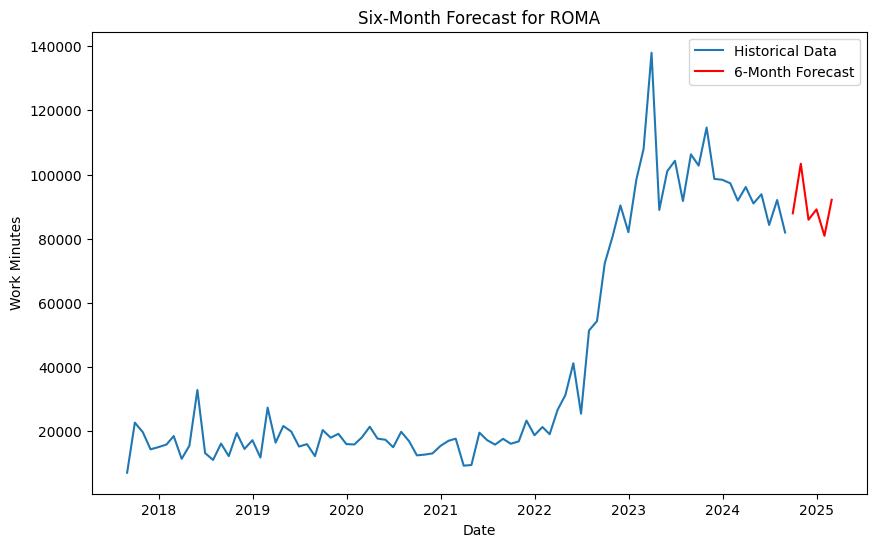

<ipython-input-6-8b89f2f0ab6a>:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data_resampled = data.resample('M').agg({
<ipython-input-6-8b89f2f0ab6a>:52: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X['trend'] = data_resampled['trend'].shift(1).fillna(method='bfill')
<ipython-input-6-8b89f2f0ab6a>:53: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X['seasonal'] = data_resampled['seasonal'].shift(1).fillna(method='bfill')
<ipython-input-6-8b89f2f0ab6a>:60: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(data_resampled.index[-1] + pd.DateOffset(months=1), periods=6, freq='M')
<ipython-input-6-8b89f2f0ab6a>:75: FutureWarning: The behavior of DataFrame concatenation with empty

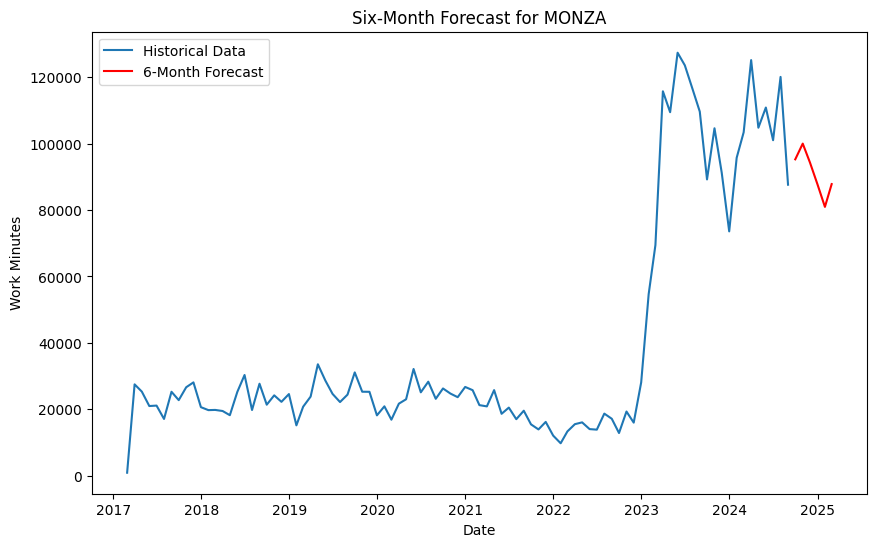

<ipython-input-6-8b89f2f0ab6a>:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data_resampled = data.resample('M').agg({
<ipython-input-6-8b89f2f0ab6a>:52: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X['trend'] = data_resampled['trend'].shift(1).fillna(method='bfill')
<ipython-input-6-8b89f2f0ab6a>:53: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X['seasonal'] = data_resampled['seasonal'].shift(1).fillna(method='bfill')
<ipython-input-6-8b89f2f0ab6a>:60: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(data_resampled.index[-1] + pd.DateOffset(months=1), periods=6, freq='M')
<ipython-input-6-8b89f2f0ab6a>:75: FutureWarning: The behavior of DataFrame concatenation with empty

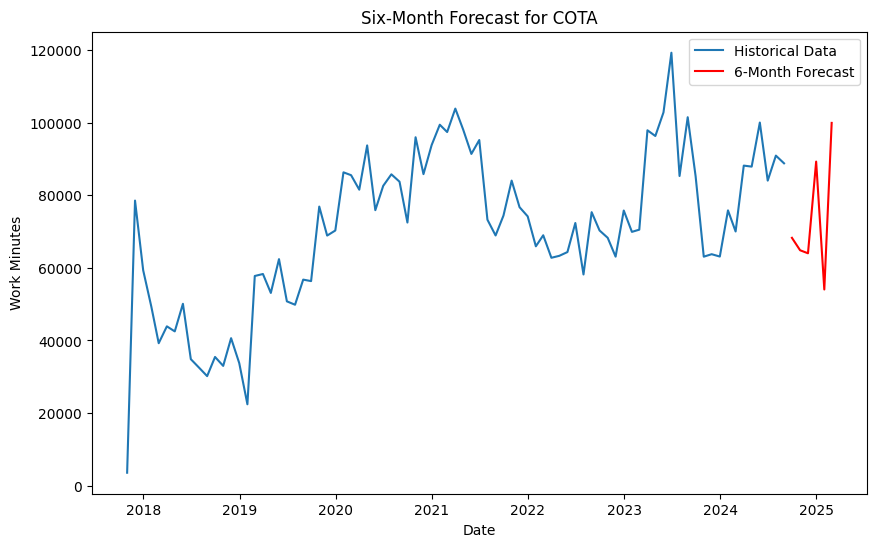

<ipython-input-6-8b89f2f0ab6a>:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data_resampled = data.resample('M').agg({
<ipython-input-6-8b89f2f0ab6a>:52: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X['trend'] = data_resampled['trend'].shift(1).fillna(method='bfill')
<ipython-input-6-8b89f2f0ab6a>:53: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X['seasonal'] = data_resampled['seasonal'].shift(1).fillna(method='bfill')
<ipython-input-6-8b89f2f0ab6a>:60: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(data_resampled.index[-1] + pd.DateOffset(months=1), periods=6, freq='M')
<ipython-input-6-8b89f2f0ab6a>:75: FutureWarning: The behavior of DataFrame concatenation with empty

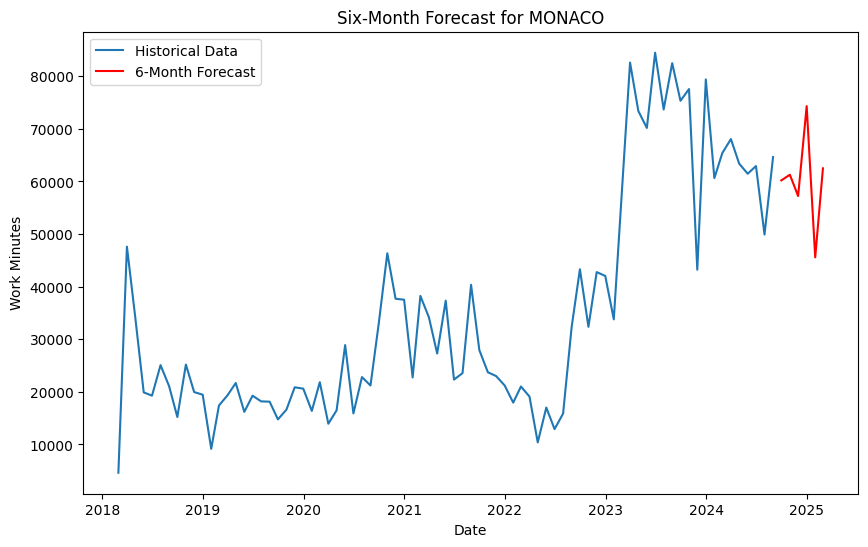

<ipython-input-6-8b89f2f0ab6a>:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data_resampled = data.resample('M').agg({
<ipython-input-6-8b89f2f0ab6a>:52: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X['trend'] = data_resampled['trend'].shift(1).fillna(method='bfill')
<ipython-input-6-8b89f2f0ab6a>:53: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X['seasonal'] = data_resampled['seasonal'].shift(1).fillna(method='bfill')
<ipython-input-6-8b89f2f0ab6a>:60: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(data_resampled.index[-1] + pd.DateOffset(months=1), periods=6, freq='M')
<ipython-input-6-8b89f2f0ab6a>:75: FutureWarning: The behavior of DataFrame concatenation with empty

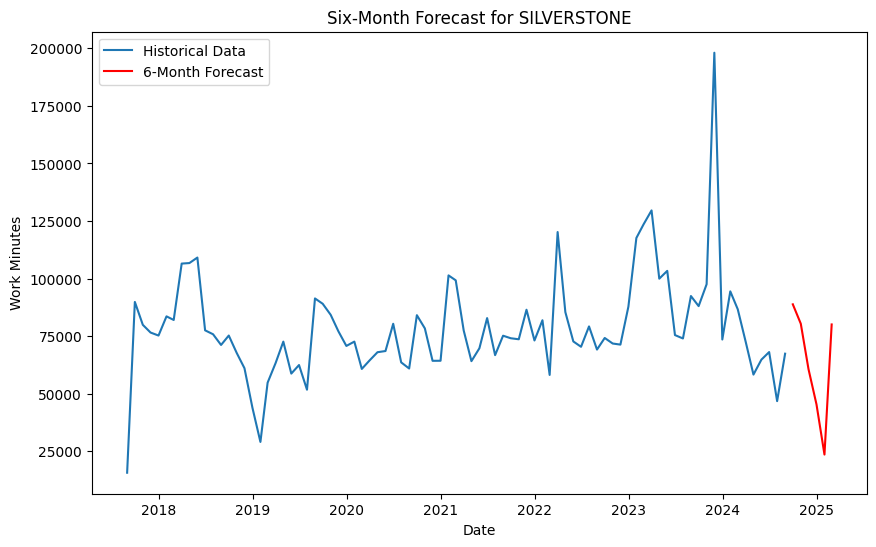

<ipython-input-6-8b89f2f0ab6a>:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data_resampled = data.resample('M').agg({
<ipython-input-6-8b89f2f0ab6a>:52: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X['trend'] = data_resampled['trend'].shift(1).fillna(method='bfill')
<ipython-input-6-8b89f2f0ab6a>:53: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X['seasonal'] = data_resampled['seasonal'].shift(1).fillna(method='bfill')
<ipython-input-6-8b89f2f0ab6a>:60: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(data_resampled.index[-1] + pd.DateOffset(months=1), periods=6, freq='M')
<ipython-input-6-8b89f2f0ab6a>:75: FutureWarning: The behavior of DataFrame concatenation with empty

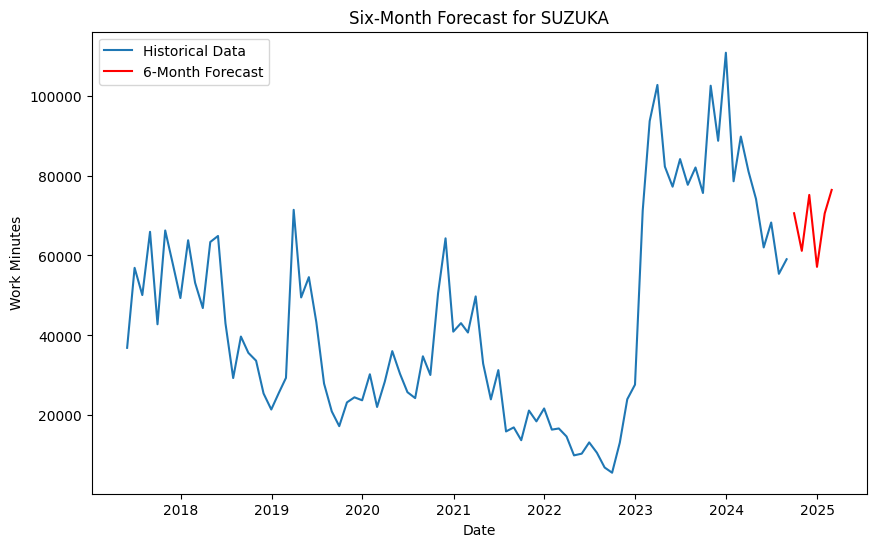

In [ ]:
import pandas as pd

# Forecast results DataFrame to store month-wise predictions
forecast_df = pd.DataFrame(columns=['Location', 'Date', 'Forecast'])
historical_data_df = pd.DataFrame(columns=['Date', 'Location', 'ACTUAL_WORK_IN_MINUTES', 'Trend', 'Seasonal', 'Residual', 'Forecast'])


# Loop to generate forecasts for each location
for location in locations:
    data = location_data[location]
    #data.set_index('EXECUTION_START_DATE', inplace=True)
    #data['Risk_Level'] = data['Risk_Level'].map({'Low Risk': 0, 'Medium Risk': 1, 'High Risk': 2})

    # Monthly resampling and seasonal decomposition
    data_resampled = data.resample('M').agg({
        'ACTUAL_WORK_IN_MINUTES': 'sum',
        'TIME_TO_FIRST_USE': 'mean',
        'TOTAL_LIFESPAN': 'mean',
        'USABLE_DURATION': 'mean',
        'TIME_USED_TO_LIFESPAN_RATIO': 'mean',
        'MAINTENANCE_FREQUENCY': 'mean',
        'MAINTENANCE_DURATION_DEVIATION': 'mean',
        'FAILURE_RISK_SCORE': 'mean',
        'Risk_Level': 'max'
    }).dropna()

    # Seasonal decomposition
    stl = STL(data_resampled['ACTUAL_WORK_IN_MINUTES'], seasonal=13)
    result = stl.fit()
    data_resampled['trend'] = result.trend
    data_resampled['seasonal'] = result.seasonal
    data_resampled['residual'] = result.resid

    # Create historical data DataFrame
    historical_data = pd.DataFrame({
        'Date': data_resampled.index,
        'Location': location,
        'ACTUAL_WORK_IN_MINUTES': data_resampled['ACTUAL_WORK_IN_MINUTES'],
        'Trend': data_resampled['trend'],
        'Seasonal': data_resampled['seasonal'],
        'Residual': data_resampled['residual']
    })

    # Prepare data with lagged features and exogenous variables
    target_col = 'residual'
    exog_cols = [
        'TIME_TO_FIRST_USE', 'TOTAL_LIFESPAN', 'USABLE_DURATION',
        'TIME_USED_TO_LIFESPAN_RATIO', 'MAINTENANCE_FREQUENCY',
        'MAINTENANCE_DURATION_DEVIATION', 'FAILURE_RISK_SCORE', 'Risk_Level'
    ]
    X, y = prepare_data(data_resampled, target_col, exog_cols)
    X['trend'] = data_resampled['trend'].shift(1).fillna(method='bfill')
    X['seasonal'] = data_resampled['seasonal'].shift(1).fillna(method='bfill')

    # Train final model on complete data
    final_model = XGBRegressor(objective='reg:squarederror', **best_params_grid)
    final_model.fit(X, y)

    # Forecast for the next 6 months
    future_dates = pd.date_range(data_resampled.index[-1] + pd.DateOffset(months=1), periods=6, freq='M')
    future_X = X[-1:].copy()  # Use last row for generating future values

    forecast = []
    for date in future_dates:
        residual_pred = final_model.predict(future_X)
        trend_value = data_resampled['trend'].iloc[-1]  # Extend last known trend value
        seasonal_value = data_resampled['seasonal'].iloc[date.month % 12 - 1]  # Match month seasonality
        total_forecast = residual_pred[0] + trend_value + seasonal_value
        forecast.append(total_forecast)

        # Append forecast result to the DataFrame
        forecast_df = pd.concat([forecast_df, pd.DataFrame([{'Location': location, 'Date': date, 'Forecast': total_forecast}])], ignore_index=True)

        # Append forecast to historical_data
        historical_data = pd.concat([historical_data, pd.DataFrame([{
            'Date': date,
            'Location': location,
            'ACTUAL_WORK_IN_MINUTES': None,  # No actual data for forecasted dates
            'Trend': trend_value,
            'Seasonal': seasonal_value,
            'Residual': residual_pred[0],
            'Forecast': total_forecast
        }])], ignore_index=True)

        # Update lagged features in `future_X` for the next prediction step
        for lag in range(12, 1, -1):
            future_X[f'{target_col}_lag_{lag}'] = future_X[f'{target_col}_lag_{lag - 1}']
        future_X[f'{target_col}_lag_1'] = residual_pred[0]

    # Append historical data for the current location to the main DataFrame
    historical_data_df = pd.concat([historical_data_df, historical_data], ignore_index=True)

    # Plot forecast results
    plt.figure(figsize=(10, 6))
    plt.plot(data_resampled.index, data_resampled['ACTUAL_WORK_IN_MINUTES'], label='Historical Data')
    plt.plot(future_dates, forecast, label='6-Month Forecast', color='red')
    plt.title(f'Six-Month Forecast for {location}')
    plt.xlabel('Date')
    plt.ylabel('Work Minutes')
    plt.legend()
    plt.show()

# Display forecasted values for each location
forecast_df['Date'] = pd.to_datetime(forecast_df['Date'])
forecast_df = forecast_df.sort_values(by=['Location', 'Date']).reset_index(drop=True)
forecast_df[['Location', 'Date', 'Forecast']]
historical_data_df.to_csv('/content/historical_data.csv', index=False)



In [ ]:
# Filter data for MONZA location
monza_data = df_cleaned[df_cleaned['PRODUCTION_LOCATION'] == 'MONACO']

# Ensure EQUIPMENT_ID column is valid
if 'EQUIPMENT_ID' not in monza_data.columns:
    raise ValueError("EQUIPMENT_ID column is missing in the filtered data.")


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Step 1: Prepare Data
# Calculate intervals for maintenance
monza_data['EXECUTION_START_DATE'] = pd.to_datetime(monza_data['EXECUTION_START_DATE'])
monza_data = monza_data.sort_values(by=['EQUIPMENT_ID', 'EXECUTION_START_DATE'])
monza_data['Maintenance_Interval_Days'] = monza_data.groupby('EQUIPMENT_ID')['EXECUTION_START_DATE'].diff().dt.days
monza_data.to_csv("monaco_data.csv", index=False)

# Drop rows with NaN intervals (first maintenance of each equipment)
monza_data = monza_data.dropna(subset=['Maintenance_Interval_Days'])

# Step 2: Feature Engineering
# Select features for prediction
features = [
    'ACTUAL_WORK_IN_MINUTES',
    'FAILURE_RISK_SCORE',
    'MAINTENANCE_FREQUENCY',
    'TIME_USED_TO_LIFESPAN_RATIO'
]

# Create lagged features for intervals
for lag in range(1, 3):
    monza_data[f'Maintenance_Interval_Lag_{lag}'] = monza_data.groupby('EQUIPMENT_ID')['Maintenance_Interval_Days'].shift(lag)

# Drop rows with NaN due to lagging
monza_data = monza_data.dropna()

# Define target variable and features
X = monza_data[features + [f'Maintenance_Interval_Lag_{lag}' for lag in range(1, 3)]]
y = monza_data['Maintenance_Interval_Days']

# Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Train a Machine Learning Model
model = RandomForestRegressor(random_state=42, n_estimators=100)
model.fit(X_train, y_train)

# Step 5: Evaluate the Model
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

# Step 6: Predict Next Maintenance Interval
last_maintenance_data = monza_data.groupby('EQUIPMENT_ID').last().reset_index()
X_last = last_maintenance_data[features + [f'Maintenance_Interval_Lag_{lag}' for lag in range(1, 3)]]

next_intervals = model.predict(X_last)

# Calculate Next Maintenance Dates
last_maintenance_data['Predicted_Next_Interval'] = next_intervals.round()
last_maintenance_data['Next_Maintenance_Date'] = (
    last_maintenance_data['EXECUTION_START_DATE'] + pd.to_timedelta(last_maintenance_data['Predicted_Next_Interval'], unit='d')
)

# Step 7: Save Results
next_maintenance_dates = last_maintenance_data[['EQUIPMENT_ID', 'EXECUTION_START_DATE', 'Predicted_Next_Interval', 'Next_Maintenance_Date']]
next_maintenance_dates.to_csv("next_maintenance_dates.csv", index=False)

print("Next maintenance dates predicted and saved.")


<ipython-input-8-7909611a3d7b>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monza_data['EXECUTION_START_DATE'] = pd.to_datetime(monza_data['EXECUTION_START_DATE'])
<ipython-input-8-7909611a3d7b>:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monza_data[f'Maintenance_Interval_Lag_{lag}'] = monza_data.groupby('EQUIPMENT_ID')['Maintenance_Interval_Days'].shift(lag)
<ipython-input-8-7909611a3d7b>:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

MAE: 22.02, RMSE: 68.73
Next maintenance dates predicted and saved.


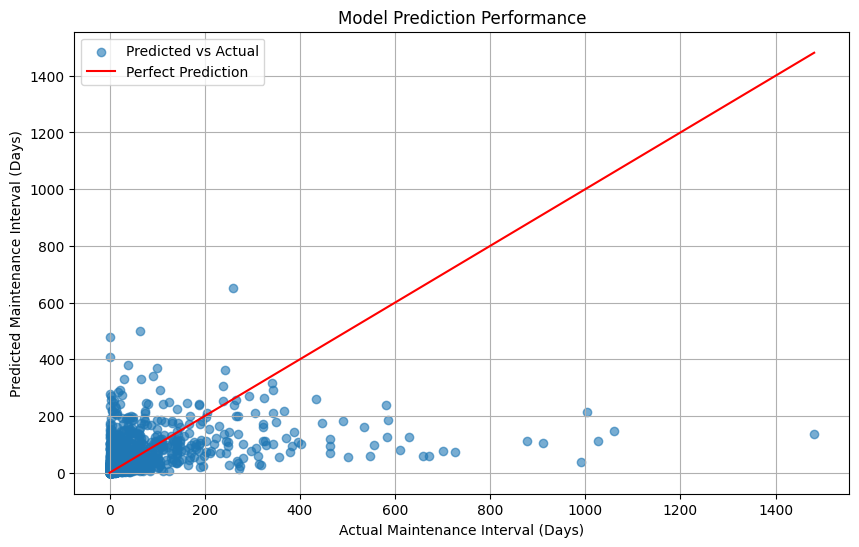

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, label="Predicted vs Actual")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', label="Perfect Prediction")
plt.xlabel("Actual Maintenance Interval (Days)")
plt.ylabel("Predicted Maintenance Interval (Days)")
plt.title("Model Prediction Performance")
plt.legend()
plt.grid()
plt.show()


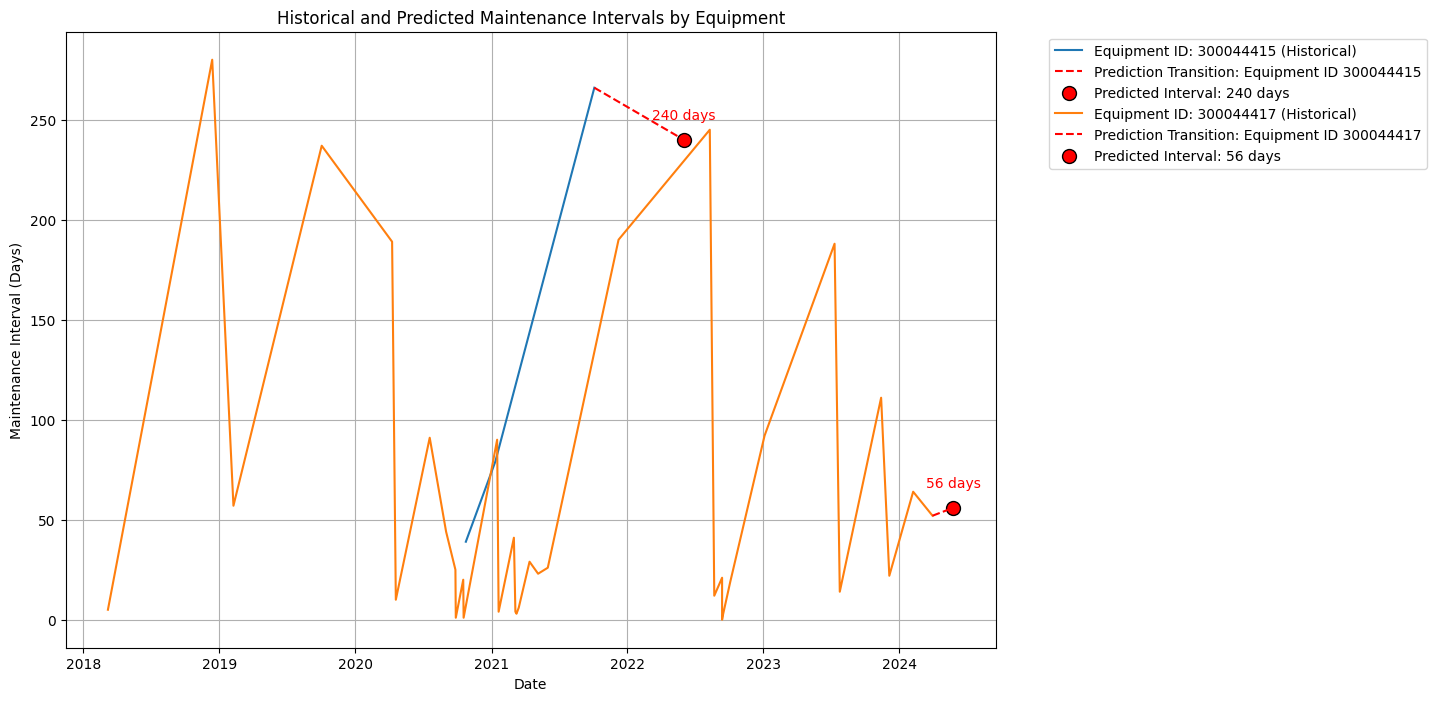

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Plot historical maintenance intervals
plt.figure(figsize=(12, 8))

equipment_ids = [300044415, 300044417]  # List of equipment IDs to plot

for equipment_id in equipment_ids:
    # Filter historical data for the equipment
    equipment_data = monza_data[monza_data['EQUIPMENT_ID'] == equipment_id]

    # Plot historical intervals
    plt.plot(
        equipment_data['EXECUTION_START_DATE'],
        equipment_data['Maintenance_Interval_Days'],
        label=f"Equipment ID: {int(equipment_id)} (Historical)"
    )

    # Add enhanced representation for next maintenance
    next_maintenance = last_maintenance_data[last_maintenance_data['EQUIPMENT_ID'] == equipment_id]
    if not next_maintenance.empty:
        next_date = next_maintenance['Next_Maintenance_Date'].values[0]
        predicted_interval = next_maintenance['Predicted_Next_Interval'].values[0]

        # Convert next_date to Python datetime for formatting
        next_date = pd.to_datetime(next_date)

        # Get the last historical point
        last_date = equipment_data['EXECUTION_START_DATE'].iloc[-1]
        last_interval = equipment_data['Maintenance_Interval_Days'].iloc[-1]

        # Connect the last point to the predicted point
        plt.plot(
            [last_date, next_date],
            [last_interval, predicted_interval],
            color='red',
            linestyle='--',
            label=f"Prediction Transition: Equipment ID {int(equipment_id)}"
        )

        # Add marker for the predicted point
        plt.scatter(
            next_date,
            predicted_interval,  # Use Predicted_Next_Interval for y-axis
            color='red',
            s=100,  # Marker size
            edgecolor='black',  # Add a black edge for visibility
            label=f"Predicted Interval: {int(predicted_interval)} days"
        )

        # Annotate the next maintenance date
        plt.text(
            next_date,
            predicted_interval + 10,  # Position annotation slightly above the marker
            f"{int(predicted_interval)} days",
            color='red',
            fontsize=10,
            ha='center'
        )

# Customize the plot
plt.title('Historical and Predicted Maintenance Intervals by Equipment')
plt.xlabel('Date')
plt.ylabel('Maintenance Interval (Days)')
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.grid()
plt.show()


<ipython-input-11-ec22c45f80d1>:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


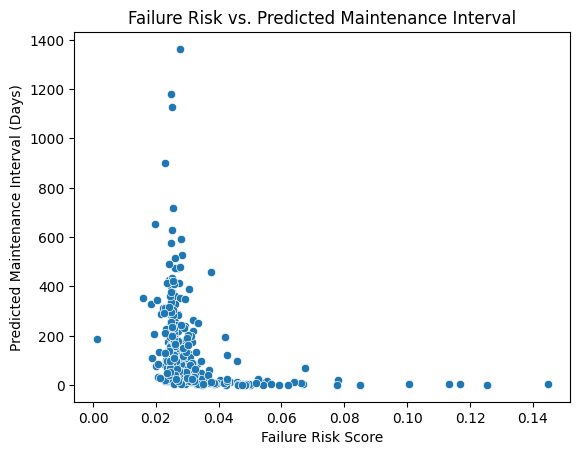

In [ ]:
sns.scatterplot(
    x=last_maintenance_data['FAILURE_RISK_SCORE'],
    y=last_maintenance_data['Predicted_Next_Interval'],
    #hue=last_maintenance_data['EQUIPMENT_ID'],
    palette='viridis'
)
plt.title('Failure Risk vs. Predicted Maintenance Interval')
plt.xlabel('Failure Risk Score')
plt.ylabel('Predicted Maintenance Interval (Days)')
plt.show()


In [ ]:
!pip install streamlit pyngrok


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.8 MB/s eta 0:00:00


In [ ]:
forecast_df.to_csv('forecasted_data.csv', index=False)

In [ ]:
from pyngrok import ngrok


In [ ]:
!ngrok config add-authtoken 1psGe9UjZuPFjgVuVuIx6iGWguG_33JKgys8r5nnNEGYU794Z

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
with open('app.py', 'w') as f:
    f.write("""
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
from datetime import datetime


# Load the forecasted data
forecast_df = pd.read_csv('/content/forecasted_data.csv')
forecast_df['Date'] = pd.to_datetime(forecast_df['Date'])

# Load historical data
try:
    historical_data = pd.read_csv('/content/historical_data.csv')
    historical_data['Date'] = pd.to_datetime(historical_data['Date'])
except FileNotFoundError:
    st.error("Historical data file not found. Please ensure 'historical_data.csv' is in the correct directory.")

# Load maintenance prediction data
try:
    maintenance_data = pd.read_csv("/content/next_maintenance_dates.csv")
    maintenance_data['EXECUTION_START_DATE'] = pd.to_datetime(maintenance_data['EXECUTION_START_DATE'])
    maintenance_data['Next_Maintenance_Date'] = pd.to_datetime(maintenance_data['Next_Maintenance_Date'])
except FileNotFoundError:
    st.error("Maintenance data file not found. Please ensure 'next_maintenance_dates.csv' is in the correct directory.")

# Load historical data for MONACO
monza_data = pd.read_csv("/content/monaco_data.csv")
monza_data['EXECUTION_START_DATE'] = pd.to_datetime(monza_data['EXECUTION_START_DATE'])

# Streamlit app title and description
st.title("Interactive Forecast Dashboard")

# Select a location to view its forecast
locations = forecast_df['Location'].unique()
selected_location = st.selectbox("Choose a Location:", locations)

# Filter forecast data by selected location
location_data = forecast_df[forecast_df['Location'] == selected_location]

# Date range slider
if 'historical_data' in locals():
    location_min_date = historical_data[historical_data['Location'] == selected_location]['Date'].min()
    location_max_date = historical_data[historical_data['Location'] == selected_location]['Date'].max()

    date_range = st.slider(
        "Select Date Range:",
        min_value=location_min_date.date(),
        max_value=location_max_date.date(),
        value=(location_min_date.date(), location_max_date.date()),
        format="YYYY-MM"
    )
    start_date = pd.to_datetime(date_range[0])
    end_date = pd.to_datetime(date_range[1])

    # Filter forecast data by date range
    location_data = location_data[(location_data['Date'] >= start_date) & (location_data['Date'] <= end_date)]

    # Display forecasted data
    st.write(f"Forecasted data for {selected_location}:")
    st.write(location_data[['Date', 'Forecast']])

    # Plot forecast data
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(location_data['Date'], location_data['Forecast'], color='red', marker='o', label='Forecast')
    ax.set_title(f"Forecast of Work Minutes for {selected_location}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Forecasted Work Minutes")
    ax.xaxis.set_major_formatter(DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)
    plt.legend()
    st.pyplot(fig)

# Checkbox to show historical data
show_historical = st.checkbox("Show Historical Data")
if show_historical and 'historical_data' in locals():
    filtered_historical_data = historical_data[
        (historical_data['Location'] == selected_location) &
        (historical_data['Date'] >= start_date) &
        (historical_data['Date'] <= end_date) &
        (historical_data['ACTUAL_WORK_IN_MINUTES'].notnull())
    ]
    st.write("Filtered Historical Data:")
    st.write(filtered_historical_data[['Date', 'ACTUAL_WORK_IN_MINUTES']])
    fig, ax = plt.subplots(figsize=(10, 6))
    if not filtered_historical_data.empty:
        ax.plot(
            filtered_historical_data['Date'],
            filtered_historical_data['ACTUAL_WORK_IN_MINUTES'],
            label='Historical Data',
            color='blue'
        )
    ax.plot(location_data['Date'], location_data['Forecast'], color='red', marker='o', label='Forecast')
    ax.set_title(f"Historical and Forecast Comparison for {selected_location}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Work Minutes")
    ax.xaxis.set_major_formatter(DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)
    plt.legend()
    st.pyplot(fig)

# Checkbox to show equipment maintenance predictions
show_equipment_maintenance = st.checkbox("Show Equipment Maintenance Predictions")
if show_equipment_maintenance:
    # Dropdown to select Equipment ID
    equipment_ids = maintenance_data['EQUIPMENT_ID'].unique()
    selected_equipment = st.selectbox("Choose an Equipment ID:", equipment_ids)

    # Filter data for the selected Equipment ID
    equipment_data = monza_data[monza_data['EQUIPMENT_ID'] == selected_equipment]
    next_maintenance = maintenance_data[maintenance_data['EQUIPMENT_ID'] == selected_equipment]

    # Plot historical and predicted maintenance intervals
    plt.figure(figsize=(12, 8))

    # Plot historical intervals
    plt.plot(
        equipment_data['EXECUTION_START_DATE'],
        equipment_data['Maintenance_Interval_Days'],
        label=f"Equipment ID: {int(selected_equipment)} (Historical)"
    )

    # Add enhanced representation for next maintenance
    if not next_maintenance.empty:
        next_date = next_maintenance['Next_Maintenance_Date'].values[0]
        predicted_interval = next_maintenance['Predicted_Next_Interval'].values[0]

        # Get the last historical point
        last_date = equipment_data['EXECUTION_START_DATE'].iloc[-1]
        last_interval = equipment_data['Maintenance_Interval_Days'].iloc[-1]

        # Connect the last point to the predicted point
        plt.plot(
            [last_date, next_date],
            [last_interval, predicted_interval],
            color='red',
            linestyle='--',
            label=f"Prediction Transition: Equipment ID {int(selected_equipment)}"
        )

        # Add marker for the predicted point
        plt.scatter(
            next_date,
            predicted_interval,
            color='red',
            s=100,
            edgecolor='black',
            label=f"Predicted Interval: {int(predicted_interval)} days"
        )

        # Annotate the next maintenance date
        plt.text(
            next_date,
            predicted_interval + 10,
            f"{int(predicted_interval)} days",
            color='red',
            fontsize=10,
            ha='center'
        )

    # Customize the plot
    plt.title(f"Historical and Predicted Maintenance Intervals for Equipment ID {int(selected_equipment)}")
    plt.xlabel("Date")
    plt.ylabel("Maintenance Interval (Days)")
    plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    plt.grid()

    # Display the plot in Streamlit
    st.pyplot(plt)

    # Display the maintenance prediction details
    st.write(f"Maintenance Prediction Details for Equipment ID: {selected_equipment}")
    st.write(next_maintenance[['EXECUTION_START_DATE', 'Predicted_Next_Interval', 'Next_Maintenance_Date']])


""")




In [ ]:
# Run Streamlit in the background
!streamlit run /content/app.py &>/dev/null &


In [ ]:
# Start ngrok tunnel for port 8501
public_url = ngrok.connect("8501", "http")
print(f'Streamlit is running on {public_url}')


Streamlit is running on NgrokTunnel: "https://9506-35-190-156-245.ngrok-free.app" -> "http://localhost:8501"
